In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",0.049103,0.298817,0.298817,1.0
…,…,…,…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",0.003124,-0.005248,0.005248,-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_local = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_score""","""pink""","""GPN-MSA""",-1
"""conservation""","""verphylop""","""#483D8B""","""Vertebrate PhyloP""",1
…,…,…,…,…
"""regulatory_nondir""","""promoterai_abs""","""#00838F""","""PromoterAI abs""",1
"""regulatory_nondir""","""abexp_abs_max""","""#80CBC4""","""AbExp abs max""",1
"""regulatory_nondir""","""fz_RNA_all_abs_max""","""#FFA500""","""Flashzoi abs max across RNA al…",1


In [4]:
# new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv40_ukbbgym.parquet"
# !dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

# new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

# new_anno_df = (
#     pl.read_parquet(new_anno_local)
#     .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
#     .with_columns(
#         fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
#         fz_blood_mean = pl.mean_horizontal(pl.col(['RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533']).abs()),
#     )
#     .select(['id', 'region', 'fz_blood_mean', 'fz_all_mean'])
#     .lazy()
# )

# new_anno_df.head().collect()

In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

min_range = -500
max_range = +500

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True),
        # (pl.any_horizontal(cs.contains("consequence_splice") == True)),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),
        # ((pl.col('consequence_intron_variant') == True) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Choose pLoF variants
        # (pl.col('loftee_hc') == True),

        # Choose protein domain
        (pl.col('ted_domain') == True),
        # (pl.col('mobi_curated_disorder_priority') == True),
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('low_complexity_domain') == True),

        # Choose regulatory region
        # (pl.col('not_in_encode') == False),
        # (pl.col('encode_eh_pr') == True),
        # (pl.col('encode_all_tf') == True),

        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range),
        # (pl.col('dist_to_tss') <= max_range),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
    )
)

# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # Gene-Body
selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing'] # missense
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['genetic_diversity', 'conservation', 'naive']    # plof comparison
# selected_categories = ['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'] # non coding
# selected_categories = ['genetic_diversity', 'splicing', 'conservation'] # introns

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
)


anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_564519/3149260291.py:88: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_564519/3149260291.py:97: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,cadd_raw,absplice2_max,delta_score,absplice_dna_max,esmscoremissense,am_pathogenicity,pangolin_score,gpn_score,verphylop,id
str,f32,f32,f32,f32,f32,f32,f32,f32,f32,str
"""ENSG00000171587""",4.852073,0.0,0.0,0.0,-4.138,0.1517,0.0,-5.79,4.402,"""chr21:40353548:C:T"""
"""ENSG00000115488""",3.37316,0.000033,0.0,0.001,-4.025,0.1124,0.0,-5.8,6.874,"""chr2:233034252:A:G"""
"""ENSG00000072274""",4.862213,0.002288,0.0,0.003,-4.298,0.25,0.01,-6.74,7.666,"""chr3:196072031:G:A"""
"""ENSG00000242515""",4.930052,0.000321,0.0,0.003,-13.379,0.9875,0.0,-8.87,6.286,"""chr2:233767094:T:C"""
"""ENSG00000288702""",-1.116719,0.000034,0.02,0.0,-3.623,0.225,0.01,-0.78,-4.731,"""chr2:233729504:G:T"""
…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000113013""",3.820372,0.002247,0.02,0.003,-5.732,0.1325,0.01,-5.92,4.541,"""chr5:138571120:C:T"""
"""ENSG00000183389""",0.834318,0.000033,0.0,0.001,-10.61,0.4547,0.0,-5.81,-1.717,"""chr11:6002594:C:G"""
"""ENSG00000288705""",4.376048,0.000341,0.0,0.003,-8.784,0.8381,0.0,-6.37,4.407,"""chr2:233768259:C:T"""


In [6]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in existing_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_564519/2939847608.py:28: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr21:40353548:C:T""","""ENSG00000171587""","""absplice_dna_max""",1
"""chr2:182186051:C:T""","""ENSG00000115252""","""absplice_dna_max""",1
"""chr17:63238053:A:G""","""ENSG00000170921""","""absplice_dna_max""",1
"""chr6:31723816:T:C""","""ENSG00000204420""","""absplice_dna_max""",1
"""chr15:62701179:C:A""","""ENSG00000171914""","""absplice_dna_max""",1


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Keep variants that don't have fillna annotation
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_564519/315562140.py:45: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr9:35699088:C:A""","""ENSG00000137076""","""esmscoremissense""",-4.246,"""missense""",-1,78815.0
"""chr2:233767853:T:A""","""ENSG00000288705""","""esmscoremissense""",-11.469,"""missense""",-1,9300.0
"""chr19:1083313:T:C""","""ENSG00000180448""","""esmscoremissense""",-4.518,"""missense""",-1,73321.0
"""chr2:1666448:C:A""","""ENSG00000130508""","""esmscoremissense""",-6.19,"""missense""",-1,49464.0
"""chr16:793175:G:C""","""ENSG00000127586""","""esmscoremissense""",-3.43,"""missense""",-1,99062.0
…,…,…,…,…,…,…
"""chr14:45136312:A:G""","""ENSG00000187790""","""verphylop""",8.179,"""conservation""",1,28860.0
"""chr16:28902630:G:A""","""ENSG00000196296""","""verphylop""",6.546,"""conservation""",1,50469.0
"""chr8:11309683:C:G""","""ENSG00000104643""","""verphylop""",-1.438,"""conservation""",1,119536.0


In [8]:
anno['region'].value_counts(sort=True).filter(pl.col('count')>=50)

region,count
str,u64
"""ENSG00000288702""",2219
"""ENSG00000241635""",2151
"""ENSG00000244474""",1960
"""ENSG00000167165""",1648
"""ENSG00000288705""",1620
…,…
"""ENSG00000164379""",53
"""ENSG00000119707""",53
"""ENSG00000100281""",52


In [9]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/quant_pheno_loftee_mac20_EURunrelated_mis
s20per_appv_percentiles_small.parquet" already exists but -f/--overwrite was
not set


## Odds ratio computation

In [10]:
n_steps = 101
min_rank_cutoff = 1_000
max_rank_cutoff = 10_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.99

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

# Prepare cutoffs once
cutoffs_sorted = (
    pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})
    .with_columns(pl.col('rank_cutoff').cast(pl.Float32))
    .sort('rank_cutoff')
    .collect()
)

cutoffs_sorted

rank_cutoff
f32
1000.0
1050.0
1103.0
1158.0
1217.0
…
111681.0
117303.0
123209.0


In [11]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Stream-collect base data ONCE: ~18M rows × 3 cols (small)
gp_base = (
    appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        is_extreme = (
            pl.when(pl.col('loftee_corr_dir') == -1)
                .then(1 - pl.col('mean_pheno_value_ptile'))
                .otherwise(pl.col('mean_pheno_value_ptile'))
            >= or_threshold_pheno
        )
    )
    .select(['id', 'region', 'is_extreme'])
    .collect(engine='streaming')
)

# Process one annotation at a time — peak RAM is ~1 annotation's worth
results = []
for annotation in tqdm(melted_anno['annotation'].unique().sort()):
    anno_ranks = (
        melted_anno
        .filter(pl.col('annotation') == annotation)
        .select(['id', 'region', 'annotation_score_dircor_rank_desc'])
    )

    rank_counts = (
        gp_base.lazy()
        .join(anno_ranks.lazy(), on=['id', 'region'], how='inner')
        .group_by('annotation_score_dircor_rank_desc')
        .agg(
            n_extreme = pl.col('is_extreme').sum().cast(pl.Int64),
            n_total = pl.len().cast(pl.Int64),
        )
        .collect()
        .sort('annotation_score_dircor_rank_desc')
        .with_columns(
            cum_extreme = pl.col('n_extreme').cum_sum(),
            cum_total = pl.col('n_total').cum_sum(),
        )
    )

    total_extreme = rank_counts['n_extreme'].sum()
    total_count = rank_counts['n_total'].sum()

    result = (
        cutoffs_sorted
        .join_asof(
            rank_counts,
            left_on='rank_cutoff',
            right_on='annotation_score_dircor_rank_desc',
            strategy='backward',
        )
        .with_columns(
            cum_extreme = pl.col('cum_extreme').fill_null(0),
            cum_total = pl.col('cum_total').fill_null(0),
        )
        .with_columns(
            annotation = pl.lit(annotation),
            n_dis_above = pl.col('cum_extreme'),
            n_notdis_above = pl.col('cum_total') - pl.col('cum_extreme'),
            n_dis_below = pl.lit(total_extreme) - pl.col('cum_extreme'),
            n_notdis_below = pl.lit(total_count - total_extreme)
                           - (pl.col('cum_total') - pl.col('cum_extreme')),
        )
        .select(['annotation', 'rank_cutoff', 'n_dis_above', 'n_notdis_above',
                 'n_dis_below', 'n_notdis_below'])
    )
    results.append(result)

# Combine (11 × 101 = 1,111 rows) and compute OR + CI
or_df = (
    pl.concat(results)
    .with_columns(
        odds_ratio = (pl.col('n_dis_above') / pl.col('n_notdis_above'))
                   / (pl.col('n_dis_below') / pl.col('n_notdis_below'))
    )
    .filter(pl.col('odds_ratio').is_finite() & (pl.col('odds_ratio') > 0))
    .with_columns(
        se_log_or = (
            1/pl.col('n_dis_above').cast(pl.Float64)
            + 1/pl.col('n_notdis_above').cast(pl.Float64)
            + 1/pl.col('n_dis_below').cast(pl.Float64)
            + 1/pl.col('n_notdis_below').cast(pl.Float64)
        ).sqrt(),
    )
    .with_columns(
        ci_lower = (pl.col('odds_ratio').cast(pl.Float64).log() - 1.96 * pl.col('se_log_or')).exp(),
        ci_upper = (pl.col('odds_ratio').cast(pl.Float64).log() + 1.96 * pl.col('se_log_or')).exp(),
    )
    .sort('rank_cutoff', descending=True)
)

or_df


100%|██████████| 9/9 [00:00<00:00, 27.50it/s]


annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,se_log_or,ci_lower,ci_upper
str,f32,i64,i64,i64,i64,f64,f64,f64,f64
"""cadd_raw""",117303.0,2060,103582,30,3055,2.025223,0.184813,1.409799,2.909301
"""esmscoremissense""",117303.0,2038,103475,52,3121,1.182113,0.141603,0.89562,1.560251
"""gpn_score""",117303.0,2062,103738,28,2899,2.057979,0.191191,1.414804,2.993544
"""verphylop""",117303.0,2047,103567,43,3070,1.411128,0.155176,1.041064,1.912737
"""absplice2_max""",111681.0,1820,91548,198,9629,0.966804,0.075596,0.833662,1.12121
…,…,…,…,…,…,…,…,…,…
"""cadd_raw""",1000.0,32,898,2058,105739,1.830895,0.18127,1.283403,2.611944
"""delta_score""",1000.0,22,901,1962,98736,1.228781,0.216989,0.8031,1.880092
"""esmscoremissense""",1000.0,57,888,2033,105708,3.337585,0.138461,2.544324,4.378168


## Plotting

In [12]:
print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        # n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = pl.col('rank_cutoff').log10(),
        log_rank_cutoff_inv = (1 / pl.col('rank_cutoff')).log10(),
    )
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('log_rank_cutoff')
    
    # Remove shaky data points
    .filter(
        (pl.col('n_dis_above')>5),
        (pl.col('n_dis_below')>5),
        (pl.col('n_notdis_above')>5),
        (pl.col('n_notdis_below')>5),
    )
)

plt_df

unique percentile cutoffs: 98


annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,se_log_or,ci_lower,ci_upper,log_rank_cutoff,log_rank_cutoff_inv,color,label,category
str,f32,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,str,str
"""absplice2_max""",1000.0,31,899,1987,100278,1.740243,0.184075,1.213171,2.496305,3.0,-3.0,"""#2E7D32""","""AbSplice2 (max)""","""splicing"""
"""absplice_dna_max""",1000.0,30,894,1982,100057,1.694055,0.186993,1.174237,2.44399,3.0,-3.0,"""#26C6DA""","""AbSplice (max)""","""splicing"""
"""am_pathogenicity""",1000.0,35,810,1965,99358,2.184858,0.174141,1.553073,3.073653,3.0,-3.0,"""#FFCA28""","""AlphaMissense""","""missense"""
"""cadd_raw""",1000.0,32,898,2058,105739,1.830895,0.18127,1.283403,2.611944,3.0,-3.0,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""delta_score""",1000.0,22,901,1962,98736,1.228781,0.216989,0.8031,1.880092,3.0,-3.0,"""#00838F""","""SpliceAI""","""splicing"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""verphylop""",111681.0,1980,98728,110,7909,1.441962,0.098654,1.188442,1.749562,5.047979,-5.047979,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""cadd_raw""",117303.0,2060,103582,30,3055,2.025223,0.184813,1.409799,2.909301,5.069309,-5.069309,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""esmscoremissense""",117303.0,2038,103475,52,3121,1.182113,0.141603,0.89562,1.560251,5.069309,-5.069309,"""#FB8C00""","""ESM1v""","""missense"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


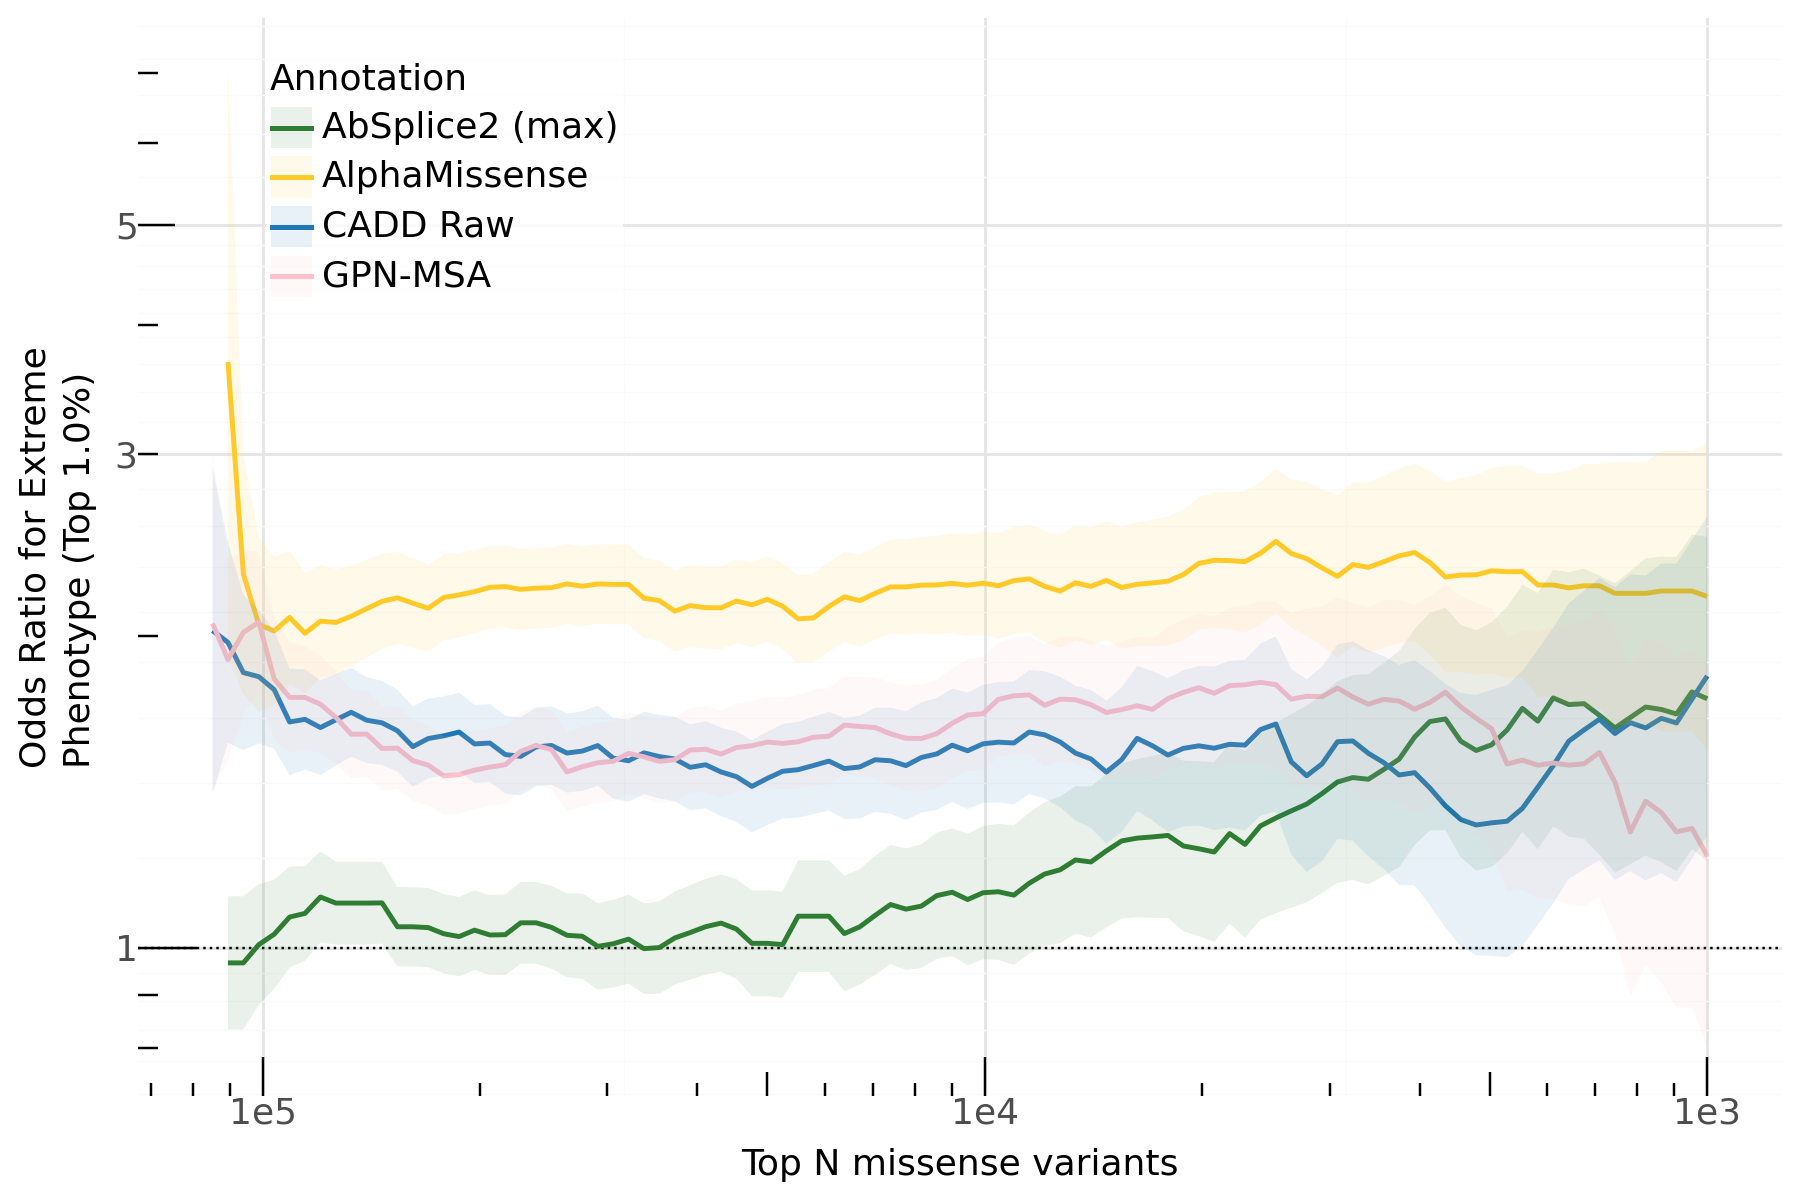

In [13]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') >= -5.5),
        # (pl.col('log_rank_cutoff_inv') <= -3),

        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_score', 'absplice2_max']))
        (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_score', 'absplice2_max', 'abexp_abs_max', 'cadd_raw']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'gpn_score']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'pangolin_score', 'delta_score', 'absplice2_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs', 'fz_RNA_blood_abs_max', 'fz_RNA_all_abs_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)


or_points = pl.DataFrame({
    'annotation': ['loftee_hc', 'loftee_hc', 'canonical_splice_variant', 'canonical_splice_variant', 'canonical_splice_variant', 'five_prime_utr_variant_consequence_uaug_gained'],
    'region': ['Gene body', 'CDS', 'Intronic', 'Intronic (no alt. CDS)', 'All Splice region', "TSS ± 500bp"],
    'n_vars': [-np.log10(131_682), -np.log10(131_682), -np.log10(1_845), -np.log10(1_764), -np.log10(29_524), -np.log10(1_505)],
    'mean_or': [4.291864, 3.707762, 2.012973, 1.860421, 3.304879, 1.156183],
    'se_or': [0.192267, 0.130931, 0.661604, 0.638351, 0.297136, 0.180272],
}).with_columns(
    ci_low_pheno = pl.col('mean_or') - 1.96 * pl.col('se_or'),
    ci_high_pheno = pl.col('mean_or') + 1.96 * pl.col('se_or'),
)

annotation = 'loftee_hc' #'loftee_hc'
plot_region = "Gene body" #'gene_body'

if plot_region in or_points['region'].unique():
    loftee_point  = [
        geom_point(
            or_points.filter(pl.col('region')==plot_region), 
            aes(x='n_vars', y='mean_or'),
            color='black',
            size=2
        ),
        geom_errorbar(
            or_points.filter(pl.col('region')==plot_region),
            aes(x='n_vars', y='mean_or', ymin='ci_low_pheno', ymax='ci_high_pheno'),
            width=0.01,
        ),
        geom_text(
            or_points.filter(pl.col('region')==plot_region),
            aes(x='n_vars', y='mean_or', label='"LOFTEE HC"'),
            nudge_x=0.1,
            # nudge_y=0.15,
            size=12,
            ha='left'
        )
    ]
else:
    loftee_point = []

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    # + loftee_point
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        # title=f"{pheno_list_type} {or_df[['region', 'phenotype']].unique().shape[0]} associations",
        y=f"Odds Ratio for Extreme\nPhenotype (Top {pheno_label}%)",
        # x=f"Top N {plot_region} variants",
        x=f"Top N missense variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(9, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.1, 0.95), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)